## Backtesting
Simulating the strategy on out-of-sample test data with transaction costs.

In [43]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


plt.style.use("dark_background")

In [44]:
prices = pd.read_csv('../data/prices.csv', index_col=0, parse_dates=True).squeeze()
returns = pd.read_csv('../data/returns.csv', index_col=0, parse_dates=True).squeeze()
target = pd.read_csv('../data/target.csv', index_col=0, parse_dates=True).squeeze()
y_pred_lr = pd.read_csv('../data/y_pred_lr.csv', index_col=0, parse_dates=True).squeeze().values
y_pred_rf = pd.read_csv('../data/y_pred_rf.csv', index_col=0, parse_dates=True).squeeze().values
y_test = pd.read_csv('../data/y_test.csv', index_col=0, parse_dates=True).squeeze()
feat_imp = pd.read_csv('../data/feat_imp.csv', index_col=0, parse_dates=False).squeeze()

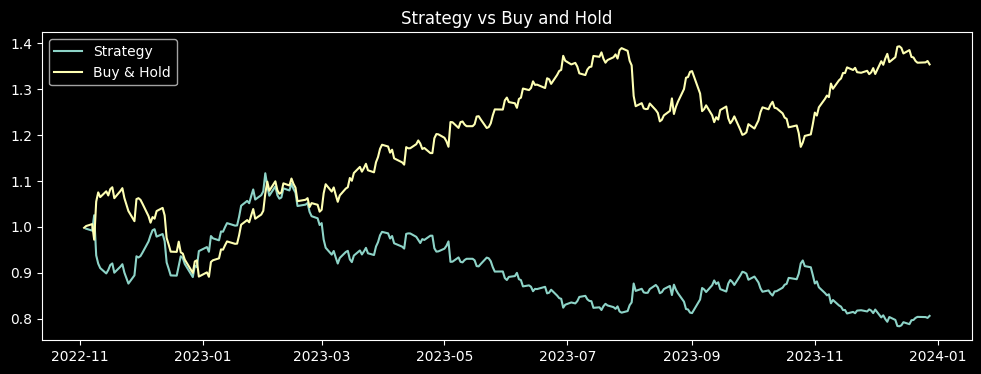

In [45]:
import pandas as pd

signal = pd.Series(np.sign(y_pred_rf), index=y_test.index)
strat_ret = signal * y_test


trades = signal.diff().abs() / 2
strat_net = strat_ret - trades * 0.001

cum_strat = (1 + strat_net).cumprod()
cum_bnh = (1 + y_test).cumprod()


plt.figure(figsize=(12, 4))
plt.plot(cum_strat, label='Strategy')
plt.plot(cum_bnh, label='Buy & Hold')
plt.title('Strategy vs Buy and Hold')
plt.legend()
plt.show()

In [46]:
def compute_metrics(ret, name=''):
    ret = ret.dropna() 
    ann_ret = ret.mean() * 252
    ann_vol = ret.std() * np.sqrt(252)
    sharpe  = ann_ret / ann_vol
    cum     = (1 + ret).cumprod()
    dd      = (cum.cummax() - cum) / cum.cummax()
    max_dd  = dd.max()
    years   = len(ret) / 252
    cagr    = cum.iloc[-1] ** (1/years) - 1
    win_rt  = (ret > 0).mean()
    return {'Name': name, 'Sharpe': round(sharpe,3), 'MaxDD': round(max_dd,4), 
            'CAGR': round(cagr,3), 'WinRate': round(win_rt,3)}

strat_metrics = compute_metrics(strat_net, 'Strategy')
bnh_metrics   = compute_metrics(y_test, 'Buy & Hold')

print(pd.DataFrame([strat_metrics, bnh_metrics]).to_string(index=False))

      Name  Sharpe  MaxDD   CAGR  WinRate
  Strategy  -0.685 0.2981 -0.172    0.472
Buy & Hold   1.248 0.1793  0.302    0.543


In [47]:
cum = (1 + strat_net).cumprod()
print(cum.head(10))
print(cum.cummax().head(10))

Date
2022-11-03         NaN
2022-11-04    0.996105
2022-11-07    0.991955
2022-11-08    1.025437
2022-11-09    0.938032
2022-11-10    0.920129
2022-11-11    0.910439
2022-11-14    0.898786
2022-11-15    0.906306
2022-11-16    0.917080
dtype: float64
Date
2022-11-03         NaN
2022-11-04    0.996105
2022-11-07    0.996105
2022-11-08    1.025437
2022-11-09    1.025437
2022-11-10    1.025437
2022-11-11    1.025437
2022-11-14    1.025437
2022-11-15    1.025437
2022-11-16    1.025437
dtype: float64


In [48]:
cum = (1 + strat_net).cumprod()
dd = (cum.cummax() - cum) / cum.cummax()

In [49]:
signal_lr = pd.Series(np.sign(y_pred_lr), index=y_test.index)
strat_ret_lr = signal_lr * y_test
trades_lr = signal_lr.diff().abs() / 2
strat_net_lr = strat_ret_lr - trades_lr * 0.001

lr_metrics = compute_metrics(strat_net_lr, 'Linear Regression')
print(lr_metrics)

{'Name': 'Linear Regression', 'Sharpe': np.float64(-1.026), 'MaxDD': np.float64(0.4139), 'CAGR': np.float64(-0.236), 'WinRate': np.float64(0.465)}


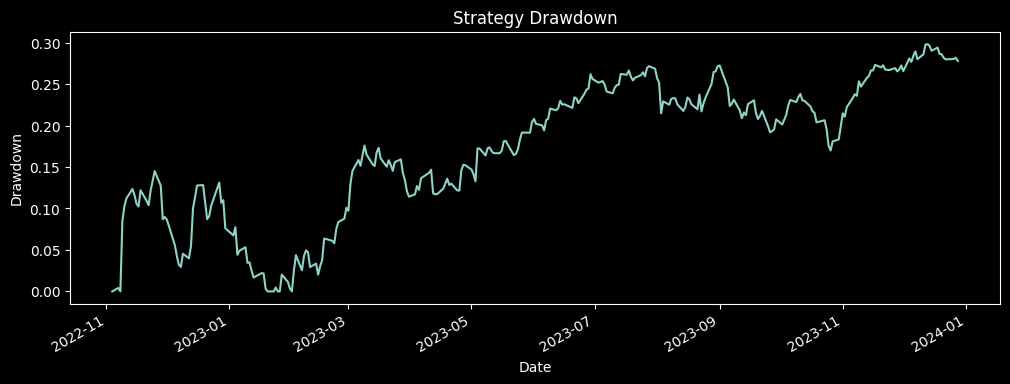

In [50]:
plt.figure(figsize=(12, 4))
dd.plot()
plt.title('Strategy Drawdown')
plt.ylabel('Drawdown')
plt.show()

In [51]:
ret_arr = strat_net.dropna().values
mc_sharpes = []

for _ in range(1000):
    resampled = np.random.choice(ret_arr, size=len(ret_arr), replace=True)
    sr = resampled.mean() * 252 / (resampled.std() * np.sqrt(252))
    mc_sharpes.append(sr)

actual_sharpe = strat_net.dropna().mean() * 252 / (strat_net.dropna().std() * np.sqrt(252))
pval = (np.array(mc_sharpes) >= actual_sharpe).mean()

print(f"Actual Sharpe: {actual_sharpe:.3f}")
print(f"MC p-value: {pval:.3f}")
print(f"5th percentile: {np.percentile(mc_sharpes, 5):.3f}")
print(f"95th percentile: {np.percentile(mc_sharpes, 95):.3f}")

Actual Sharpe: -0.685
MC p-value: 0.496
5th percentile: -2.269
95th percentile: 0.858


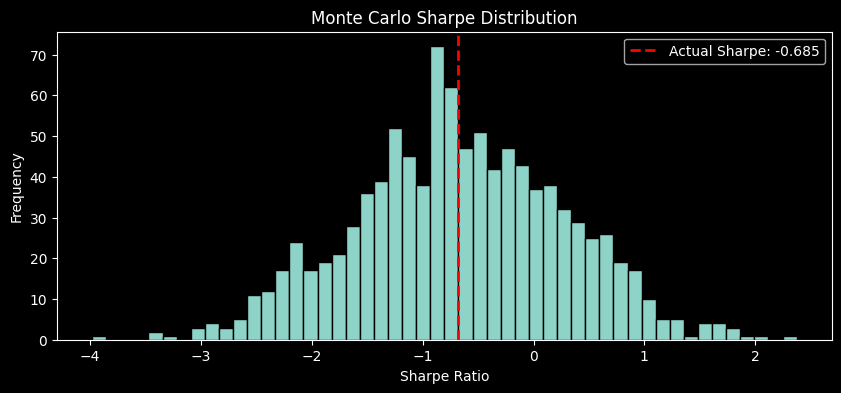

In [52]:
plt.figure(figsize=(10, 4))
plt.hist(mc_sharpes, bins=50, edgecolor='black')
plt.axvline(actual_sharpe, color='red', linestyle='--', linewidth=2, label=f'Actual Sharpe: {actual_sharpe:.3f}')
plt.title('Monte Carlo Sharpe Distribution')
plt.xlabel('Sharpe Ratio')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [53]:

plt.figure(figsize=(10, 4))
plt.hist(mc_sharpes, bins=50, edgecolor='black')
plt.axvline(actual_sharpe, color='red', linestyle='--', linewidth=2, label=f'Actual Sharpe: {actual_sharpe:.3f}')
plt.title('Monte Carlo Sharpe Distribution')
plt.xlabel('Sharpe Ratio')
plt.legend()
plt.savefig('../results/monte_carlo.png', dpi=150, bbox_inches='tight')
plt.close()


plt.figure(figsize=(12, 4))
plt.plot(cum_strat, label='Strategy')
plt.plot(cum_bnh, label='Buy & Hold')
plt.title('Strategy vs Buy and Hold')
plt.legend()
plt.savefig('../results/equity_curve.png', dpi=150, bbox_inches='tight')
plt.close()


feat_imp.sort_values().tail(15).plot(kind='barh', figsize=(10, 6))
plt.title('Random Forest Feature Importances')
plt.savefig('../results/feature_importance.png', dpi=150, bbox_inches='tight')
plt.close()

print("All plots saved.")

All plots saved.
